In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
from sklearn.preprocessing import StandardScaler
import time
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
# --- 1. Configuration and Hyperparameters ---
CONFIG = {
    "data_path_facies": "../data/facies_uncropped.npy",
    "data_path_properties": "../data/parameters.csv",
    "epochs": 50,
    "batch_size": 32,
    "learning_rate": 0.001,
    "test_split": 0.1,
    "validation_split": 0.1,
    "seed": 42,
}

# For reproducibility
torch.manual_seed(CONFIG["seed"])
torch.Generator().manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

In [3]:
# --- 2. Custom PyTorch Dataset ---
class GeologyDataset(Dataset):
    """Custom Dataset for loading the 3D geological models."""
    def __init__(self, facies, properties):
        self.facies = torch.from_numpy(facies).float().unsqueeze(1)
        targets = properties[:,:5]
        self.scaler = StandardScaler()
        self.targets = torch.from_numpy(self.scaler.fit_transform(targets)).float()
        self.angle_ntg = properties[:,5:]

    def __len__(self):
        return len(self.facies)

    def __getitem__(self, idx):
        return self.facies[idx], self.targets[idx], self.angle_ntg[idx]

In [ ]:
# --- 3. The 3D CNN Model Architecture ---
from genflows.models.cnn3d import CNN3D

In [5]:
# --- 4. Training and Evaluation Loop ---
def train_model(model, train_loader, val_loader, device):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
    
    best_val_loss = float('inf')
    
    # --- MODIFIED: Store history of losses ---
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(CONFIG["epochs"]):
        start_time = time.time()
        model.train()
        train_loss = 0.0
        for inputs, targets, _ in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets, _ in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        
        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_time = time.time() - start_time

        # --- MODIFIED: Append losses to history ---
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)

        print(f"Epoch {epoch+1}/{CONFIG['epochs']}.. "
              f"Train Loss: {epoch_train_loss:.4f}.. "
              f"Val Loss: {epoch_val_loss:.4f}.. "
              f"Time: {epoch_time:.2f}s")

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), 'cnn3d_property_predictor.pth')
            print(f"   -> New best model saved with validation loss: {best_val_loss:.4f}")

    # --- MODIFIED: Return the history ---
    return history

# --- NEW: Function to plot loss curves ---
def plot_loss_curves(history):
    """Plots the training and validation loss curves."""
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.ylim(-0.01, 0.47)
    plt.legend()
    plt.grid(True)
    plt.savefig('loss_curves.png') # Save the plot to a file
    print("\nLoss curves plot saved as 'loss_curves.png'")
    plt.show()

Using device: cuda
Loading data...
facies data shape is (100000, 50, 50, 50)
Properties data shape is (100000, 7)
          height     radius  aspect_ratio       sin       cos       angle  \
0      22.241179  24.987935      2.612826  0.329598  0.944121    9.622203   
1      32.143781   7.896597      1.070346 -0.466528 -0.884506  103.904591   
2      38.867897  19.448352      2.127520  0.804140 -0.594439   63.236336   
3       9.247145  13.745991      1.680743 -0.982992  0.183647  140.291141   
4      14.282052  21.319003      1.461311 -0.169330  0.985559  175.125575   
...          ...        ...           ...       ...       ...         ...   
99995  13.197542   3.932245      2.542588  0.097410  0.995244    2.795014   
99996   8.164009  23.304992      2.323155  0.998014  0.062987   43.194366   
99997  38.720868   9.599365      1.860753 -0.757663 -0.652646  114.629300   
99998  30.415770  17.664887      2.933552  0.531234 -0.847225   73.955555   
99999  20.199352  15.351534      1.3754

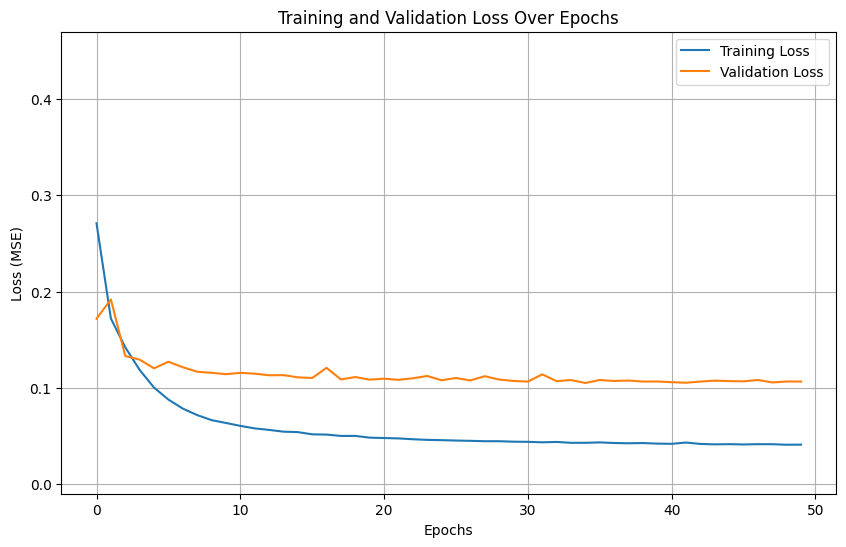


Evaluating on the test set...
Final Test MSE Loss: 0.1077


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Loading data...")
facies_data = np.load(CONFIG["data_path_facies"])[:,:,:,10:-60]
print("facies data shape is", facies_data.shape)
properties_data = pd.read_csv(CONFIG["data_path_properties"])[["height","radius","aspect_ratio","angle","net_to_gross"]]
# angle = properties_data["angle"]
# ntg = properties_data["net_to_gross"]
# properties_data = properties_data[["height","radius","aspect_ratio"]]
properties_data["sin"] = np.sin(2*properties_data["angle"].values*np.pi/180)
properties_data["cos"] = np.cos(2*properties_data["angle"].values*np.pi/180)
properties_data = properties_data[["height","radius","aspect_ratio","sin","cos","angle","net_to_gross"]]
print("Properties data shape is", properties_data.shape)
print(properties_data)
print("Data loaded successfully.")

failed_cases = np.load("../data/failed_cases.npy")
full_dataset = GeologyDataset(np.delete(facies_data, failed_cases, axis=0), np.delete(properties_data.values, failed_cases, axis=0))

test_size = int(CONFIG["test_split"] * len(full_dataset))
val_size = int(CONFIG["validation_split"] * len(full_dataset))
train_size = len(full_dataset) - test_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

print(f"Dataset split into: Train={len(train_dataset)}, Validation={len(val_dataset)}, Test={len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

model = CNN3D().to(device)
print("\nModel Architecture:")
print(model)

print("\nStarting training...")
# --- Capture the returned history ---
training_history = train_model(model, train_loader, val_loader, device)
print("Training finished.")

# --- Plot the captured history ---
plot_loss_curves(training_history)

print("\nEvaluating on the test set...")
model.load_state_dict(torch.load('cnn3d_property_predictor.pth'))
model.eval()
test_loss = 0.0
criterion = nn.MSELoss()

with torch.no_grad():
    for inputs, targets, _ in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)
        
final_test_loss = test_loss / len(test_loader.dataset)
print(f"Final Test MSE Loss: {final_test_loss:.4f}")


📈 Loss curves plot saved as 'loss_curves.png'


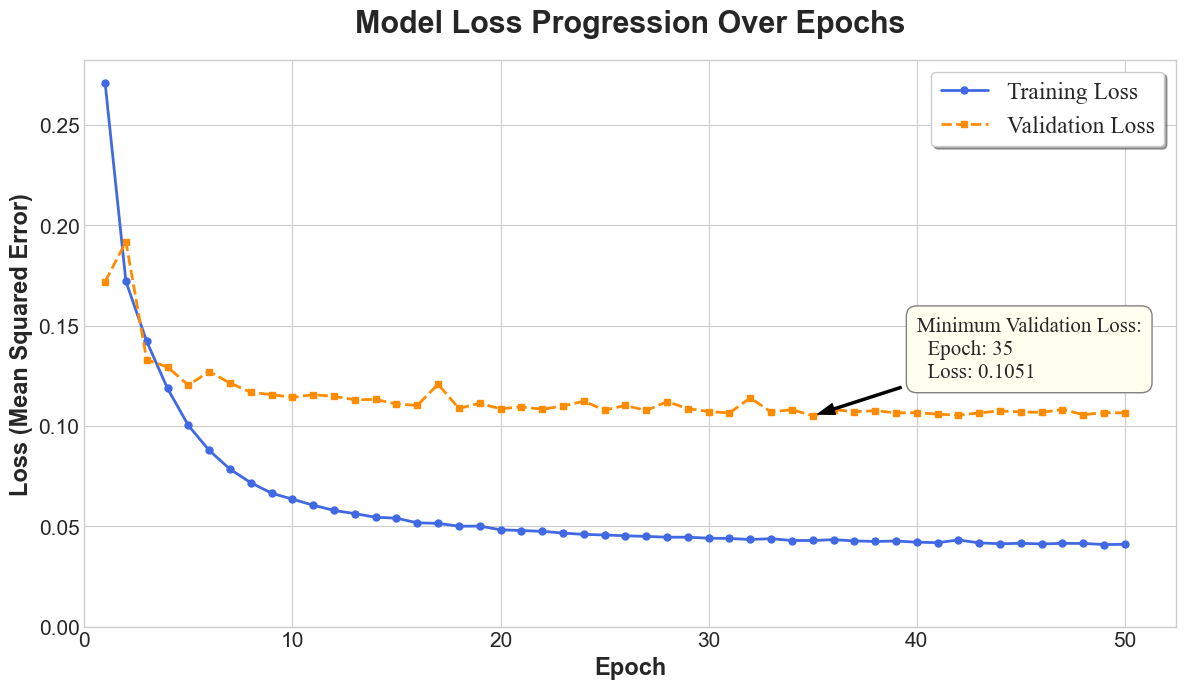

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_loss_curves(history, save_path="loss_curves.png"):
    """
    Plots aesthetically enhanced training and validation loss curves.

    This function uses a professional style, clear color distinction, and highlights
    the epoch with the minimum validation loss for better analysis.

    Args:
        history (dict): A dictionary containing 'train_loss' and 'val_loss' lists or arrays.
        save_path (str, optional): The file path to save the plot image. 
                                   Defaults to "loss_curves.png".
    """
    # Use a clean and professional plot style
    plt.style.use('seaborn-v0_8-whitegrid')

    # Create a figure and axes object for more control over the plot
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)

    # Determine the number of epochs from the length of the loss list
    epochs = range(1, len(history['train_loss']) + 1)
    # Set the default font to Times New Roman for all text elements
    # Plot training & validation loss with distinct colors and markers
    ax.plot(epochs, history['train_loss'], color='royalblue', marker='o', linestyle='-', linewidth=2, markersize=5, label='Training Loss')
    ax.plot(epochs, history['val_loss'], color='darkorange', marker='s', linestyle='--', linewidth=2, markersize=5, label='Validation Loss')

    # --- Cosmetic & Informational Enhancements ---

    # Add a clear title and labels with bold font
    ax.set_title('Model Loss Progression Over Epochs', fontsize=22, fontweight='bold', pad=20)
    ax.set_xlabel('Epoch', fontsize=17, fontweight='bold')
    ax.set_ylabel('Loss (Mean Squared Error)', fontsize=17, fontweight='bold')
    
    # Customize the legend for better readability
    ax.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = 'Times New Roman'
    
    # Set axis limits. Start y-axis at 0, as loss cannot be negative.
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=0)

    # Find the epoch with the minimum validation loss to highlight it
    min_val_loss = min(history['val_loss'])
    min_val_epoch = history['val_loss'].index(min_val_loss) + 1

    # Add an annotation for the minimum validation loss point
    ax.annotate(f'Minimum Validation Loss:\n  Epoch: {min_val_epoch}\n  Loss: {min_val_loss:.4f}',
                xy=(min_val_epoch, min_val_loss),
                xytext=(min_val_epoch + 0.1*len(epochs), min_val_loss + 0.1*max(history['val_loss'])),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                fontsize=15,
                bbox=dict(boxstyle="round,pad=0.5", fc="ivory", ec="gray", lw=1))
    
    # Adjust tick label size
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.legend(loc='upper right', fontsize=17, frameon=True, shadow=True)
    # Ensure the layout is tight
    plt.tight_layout()
    
    # Save the plot with high resolution
    plt.savefig(save_path, dpi=300)
    print(f"\n📈 Loss curves plot saved as '{save_path}'")
    
    # plt.savefig("C:/Users/er34726/Downloads/paper4/Fig9.pdf", bbox_inches='tight')
    plt.show()


# --- NEW: Plot the captured history ---
plot_loss_curves(training_history)

In [8]:
def get_predictions(model, data_loader, device):
    """Gets model predictions for a given dataset."""
    model.eval()  # Set the model to evaluation mode
    all_predictions = []
    all_targets = []
    all_angle_ntgs = []
    all_inputs = []
    with torch.no_grad():
        for inputs, targets, angl_ntg in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            angl_ntg = angl_ntg.to(device)
            
            outputs = model(inputs)
            all_inputs.append(inputs.cpu())
            all_predictions.append(outputs.cpu())
            all_targets.append(targets.cpu())
            all_angle_ntgs.append(angl_ntg.cpu())
            
    inputs_tensor = torch.cat(all_inputs)
    predictions_tensor = torch.cat(all_predictions)
    targets_tensor = torch.cat(all_targets)
    angl_ntgs_tensor = torch.cat(all_angle_ntgs)
    return inputs_tensor, predictions_tensor, targets_tensor, angl_ntgs_tensor

# --- MODIFIED: Load the best model and get predictions for BOTH train and test sets ---
print("\nLoading best model and generating predictions...")
model.load_state_dict(torch.load('cnn3d_property_predictor.pth'))

# Get raw predictions (these are still normalized)
train_inputs_tensor, train_preds_tensor, train_targets_tensor, train_angl_ntgs_tensor = get_predictions(model, train_loader, device)
test_inputs_tensor, test_preds_tensor, test_targets_tensor, test_angl_ntgs_tensor = get_predictions(model, test_loader, device)

# Use the scaler from your dataset to convert values back to original scale
scaler = full_dataset.scaler

inputs_train = train_inputs_tensor.numpy()
inputs_test = test_inputs_tensor.numpy()
facies_grid_sum_train = inputs_train.sum(axis=(1,2,3,4))
facies_grid_sum_test = inputs_test.sum(axis=(1,2,3,4))
print("shapes are ", inputs_test.shape, facies_grid_sum_test.shape)
train_mask = (facies_grid_sum_train>12500) & (facies_grid_sum_train<112500)
test_mask = (facies_grid_sum_test>12500) & (facies_grid_sum_test<112500)

# --- Create variables for the training set ---
predicted_values_train = scaler.inverse_transform(train_preds_tensor.numpy())[train_mask]
actual_values_train = scaler.inverse_transform(train_targets_tensor.numpy())[train_mask]
actual_angl_ntgs_values_train = train_angl_ntgs_tensor.numpy()[train_mask]

# --- Create variables for the test set ---
predicted_values_test = scaler.inverse_transform(test_preds_tensor.numpy())[test_mask]
actual_values_test = scaler.inverse_transform(test_targets_tensor.numpy())[test_mask]
actual_angl_ntgs_values_test = test_angl_ntgs_tensor.numpy()[test_mask]

print("\nPrediction analysis complete")


Loading best model and generating predictions...
shapes are  (9993, 1, 50, 50, 50) (9993,)

Prediction analysis complete


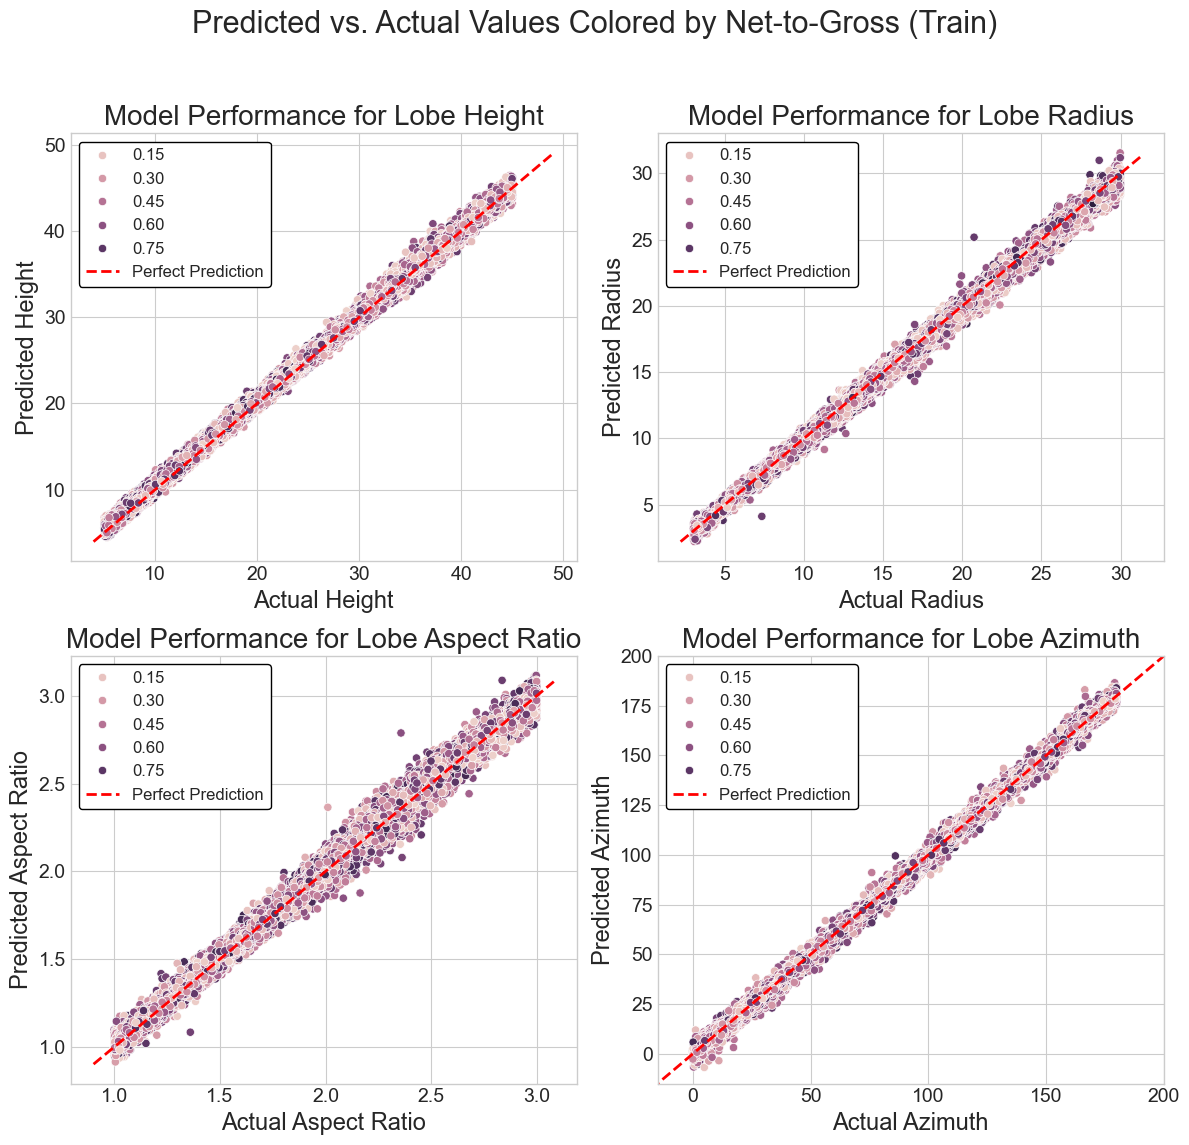

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Unpack all the data from the previous cell ---
# Training data
actual_h_train = actual_values_train[:, 0]
predicted_h_train = predicted_values_train[:, 0]
actual_r_train = actual_values_train[:, 1]
predicted_r_train = predicted_values_train[:, 1]
actual_asp_train = actual_values_train[:, 2]
predicted_asp_train = predicted_values_train[:, 2]
actual_anglsin_train = actual_values_train[:, 3]
predicted_anglsin_train = predicted_values_train[:, 3]
actual_anglcos_train = actual_values_train[:, 4]
predicted_anglcos_train = predicted_values_train[:, 4]
actual_angl_train = np.arctan2(actual_anglsin_train, actual_anglcos_train) / np.pi * 180
predicted_angl_train = np.arctan2(predicted_anglsin_train, predicted_anglcos_train) / np.pi * 180
actual_angl_train[actual_angl_train<0] += 360
predicted_angl_train[predicted_angl_train<0] += 360
actual_angl_train /= 2
predicted_angl_train /= 2
angl_residuals_train = actual_angl_train - predicted_angl_train
predicted_angl_train[angl_residuals_train < -90] -= 180
predicted_angl_train[angl_residuals_train > 90] += 180
actual_angl_train_real = actual_angl_ntgs_values_train[:, 0]
actual_ntg_train_real = actual_angl_ntgs_values_train[:, 1]

# Test data
actual_h_test = actual_values_test[:, 0]
predicted_h_test = predicted_values_test[:, 0]
actual_r_test = actual_values_test[:, 1]
predicted_r_test = predicted_values_test[:, 1]
actual_asp_test = actual_values_test[:, 2]
predicted_asp_test = predicted_values_test[:, 2]
actual_anglsin_test = actual_values_test[:, 3]
predicted_anglsin_test = predicted_values_test[:, 3]
actual_anglcos_test = actual_values_test[:, 4]
predicted_anglcos_test = predicted_values_test[:, 4]
actual_angl_test = np.arctan2(actual_anglsin_test, actual_anglcos_test) / np.pi * 180
predicted_angl_test = np.arctan2(predicted_anglsin_test, predicted_anglcos_test) / np.pi * 180
actual_angl_test[actual_angl_test<0] += 360
predicted_angl_test[predicted_angl_test<0] += 360
actual_angl_test /= 2
predicted_angl_test /= 2
angl_residuals_test = actual_angl_test - predicted_angl_test
predicted_angl_test[angl_residuals_test < -90] -= 180
predicted_angl_test[angl_residuals_test > 90] += 180
actual_angl_test_real = actual_angl_ntgs_values_test[:, 0]
actual_ntg_test_real = actual_angl_ntgs_values_test[:, 1]

# Legend settings to reuse
legend_params = {
    'fontsize': 12,
    'frameon': True,     # Ensures the box is drawn
    'facecolor': 'white', # Sets background to white
    'edgecolor': 'black', # Optional: adds a black border for definition
    'framealpha': 1      # Ensures the box is 100% opaque
}
# Create a figure with two subplots
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Predicted vs. Actual Values Colored by Net-to-Gross (Train)', fontsize=22)


# --- Plot for Height ---
# Plot training data
sns.scatterplot(x=actual_h_train, y=predicted_h_train, ax=ax[0,0], hue=actual_ntg_train_real)

ax[0,0].set_title('Model Performance for Lobe Height', fontsize=20)
ax[0,0].set_xlabel('Actual Height', fontsize=17)
ax[0,0].set_ylabel('Predicted Height', fontsize=17)
min_h, max_h = min(actual_h_test.min(), predicted_h_test.min()), max(actual_h_test.max(), predicted_h_test.max())
# ax[0,0].plot([min_h, max_h], [min_h, max_h], 'r--', lw=2, label='Expectation') # Changed label here
ax[0,0].plot([min_h, max_h], [min_h, max_h], 'r--', lw=2, label='Perfect Prediction')
ax[0,0].legend(**legend_params)
ax[0,0].grid(True)
ax[0,0].tick_params(axis='both', labelsize=14)

# --- Plot for Radius ---
# Plot training data
sns.scatterplot(x=actual_r_train, y=predicted_r_train, ax=ax[0,1], hue=actual_ntg_train_real)

ax[0,1].set_title('Model Performance for Lobe Radius', fontsize=20)
ax[0,1].set_xlabel('Actual Radius', fontsize=17)
ax[0,1].set_ylabel('Predicted Radius', fontsize=17)
min_r, max_r = min(actual_r_test.min(), predicted_r_test.min()), max(actual_r_test.max(), predicted_r_test.max())
ax[0,1].plot([min_r, max_r], [min_r, max_r], 'r--', lw=2, label='Perfect Prediction')
ax[0,1].legend(**legend_params)
ax[0,1].grid(True)
ax[0,1].tick_params(axis='both', labelsize=14)

# --- Plot for Aspect Ratio ---
# Plot training data
sns.scatterplot(x=actual_asp_train, y=predicted_asp_train, ax=ax[1,0], hue=actual_ntg_train_real)

ax[1,0].set_title('Model Performance for Lobe Aspect Ratio', fontsize=20)
ax[1,0].set_xlabel('Actual Aspect Ratio', fontsize=17)
ax[1,0].set_ylabel('Predicted Aspect Ratio', fontsize=17)
min_r, max_r = min(actual_asp_test.min(), predicted_asp_test.min()), max(actual_asp_test.max(), predicted_asp_test.max())
ax[1,0].plot([min_r, max_r], [min_r, max_r], 'r--', lw=2, label='Perfect Prediction')
ax[1,0].legend(**legend_params)
ax[1,0].grid(True)
ax[1,0].tick_params(axis='both', labelsize=14)

# --- Plot for Angle ---
# Plot training data
sns.scatterplot(x=actual_angl_train_real, y=predicted_angl_train, ax=ax[1,1], hue=actual_ntg_train_real)

ax[1,1].set_title('Model Performance for Lobe Azimuth', fontsize=20)
ax[1,1].set_xlabel('Actual Azimuth', fontsize=17)
ax[1,1].set_ylabel('Predicted Azimuth', fontsize=17)
min_r, max_r = min(actual_angl_test.min(), predicted_angl_test.min()), max(actual_angl_test.max(), predicted_angl_test.max())
ax[1,1].plot([min_r, max_r], [min_r, max_r], 'r--', lw=2, label='Perfect Prediction')
ax[1,1].legend(**legend_params)
ax[1,1].grid(True)
ax[1,1].tick_params(axis='both', labelsize=14)
ax[1,1].set_xlim(-15, 200)
ax[1,1].set_ylim(-15, 200)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle

plt.savefig("C:/Users/er34726/Downloads/paper4/Fig14.tif", bbox_inches='tight')
plt.show()

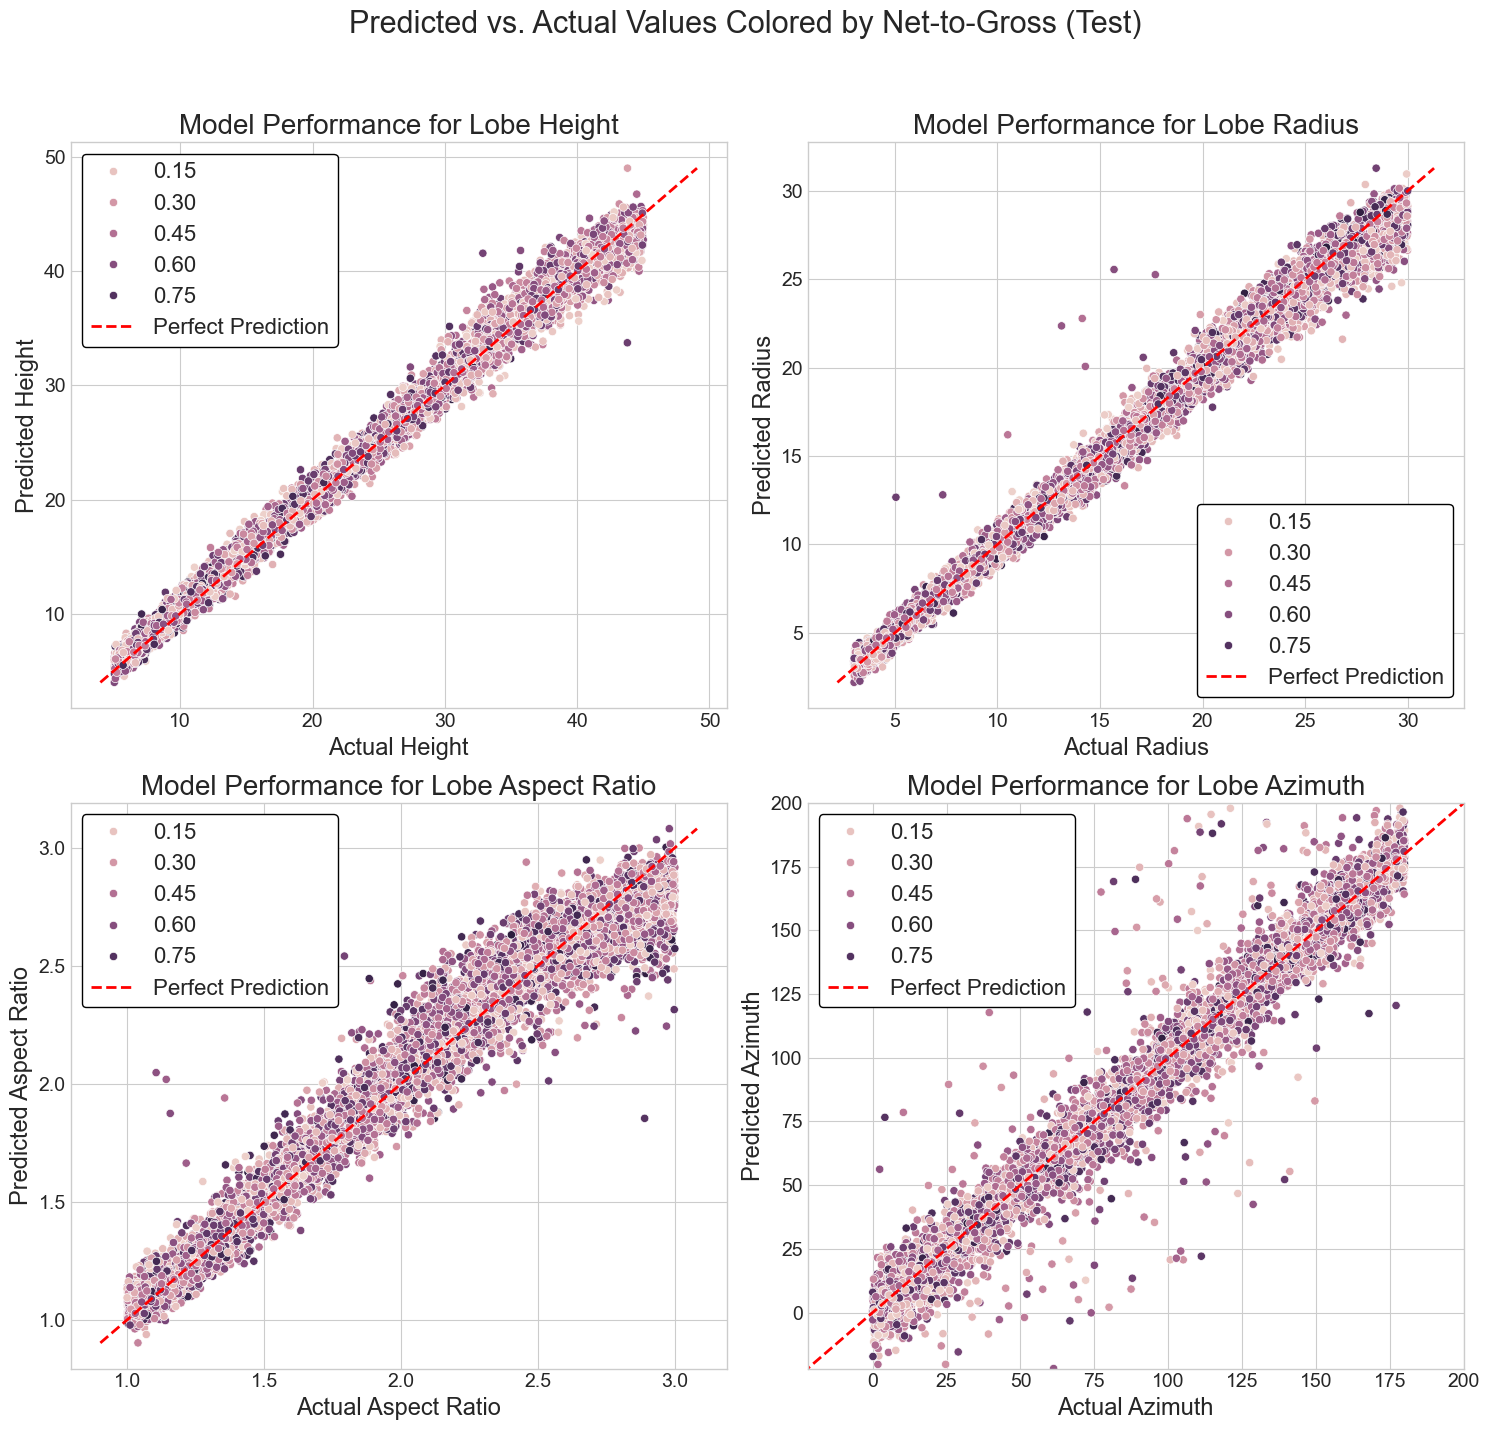

In [72]:
# Create a figure with two subplots
fig, ax = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle('Predicted vs. Actual Values Colored by Net-to-Gross (Test)', fontsize=22)


# --- Plot for Height ---
# Plot test data (orange, more opaque)
sns.scatterplot(x=actual_h_test, y=predicted_h_test, ax=ax[0,0], hue=actual_ntg_test_real)

ax[0,0].set_title('Model Performance for Lobe Height', fontsize=20)
ax[0,0].set_xlabel('Actual Height', fontsize=17)
ax[0,0].set_ylabel('Predicted Height', fontsize=17)
min_h, max_h = min(actual_h_test.min(), predicted_h_test.min()), max(actual_h_test.max(), predicted_h_test.max())
# ax[0,0].plot([min_h, max_h], [min_h, max_h], 'r--', lw=2, label='Expectation') # Changed label here
ax[0,0].plot([min_h, max_h], [min_h, max_h], 'r--', lw=2, label='Perfect Prediction')
ax[0,0].legend(**legend_params)
ax[0,0].grid(True)
ax[0,0].tick_params(axis='both', labelsize=14)

# --- Plot for Radius ---
# Plot test data
sns.scatterplot(x=actual_r_test, y=predicted_r_test, ax=ax[0,1], hue=actual_ntg_test_real)

ax[0,1].set_title('Model Performance for Lobe Radius', fontsize=20)
ax[0,1].set_xlabel('Actual Radius', fontsize=17)
ax[0,1].set_ylabel('Predicted Radius', fontsize=17)
min_r, max_r = min(actual_r_test.min(), predicted_r_test.min()), max(actual_r_test.max(), predicted_r_test.max())
ax[0,1].plot([min_r, max_r], [min_r, max_r], 'r--', lw=2, label='Perfect Prediction')
ax[0,1].legend(**legend_params)
ax[0,1].grid(True)
ax[0,1].tick_params(axis='both', labelsize=14)

# --- Plot for Aspect Ratio ---
# Plot test data
sns.scatterplot(x=actual_asp_test, y=predicted_asp_test, ax=ax[1,0], hue=actual_ntg_test_real)

ax[1,0].set_title('Model Performance for Lobe Aspect Ratio', fontsize=20)
ax[1,0].set_xlabel('Actual Aspect Ratio', fontsize=17)
ax[1,0].set_ylabel('Predicted Aspect Ratio', fontsize=17)
min_r, max_r = min(actual_asp_test.min(), predicted_asp_test.min()), max(actual_asp_test.max(), predicted_asp_test.max())
ax[1,0].plot([min_r, max_r], [min_r, max_r], 'r--', lw=2, label='Perfect Prediction')
ax[1,0].legend(**legend_params)
ax[1,0].grid(True)
ax[1,0].tick_params(axis='both', labelsize=14)

# --- Plot for Angle ---
# Plot test data
sns.scatterplot(x=actual_angl_test_real, y=predicted_angl_test, ax=ax[1,1], hue=actual_ntg_test_real)

ax[1,1].set_title('Model Performance for Lobe Azimuth', fontsize=20)
ax[1,1].set_xlabel('Actual Azimuth', fontsize=17)
ax[1,1].set_ylabel('Predicted Azimuth', fontsize=17)
min_r, max_r = min(actual_angl_test.min(), predicted_angl_test.min()), max(actual_angl_test.max(), predicted_angl_test.max())
ax[1,1].plot([min_r, max_r], [min_r, max_r], 'r--', lw=2, label='Perfect Prediction')
ax[1,1].legend(**legend_params)
ax[1,1].grid(True)
ax[1,1].tick_params(axis='both', labelsize=14)
ax[1,1].set_xlim(-22, 200)
ax[1,1].set_ylim(-22, 200)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle

plt.savefig("C:/Users/er34726/Downloads/paper4/Fig15.tif", bbox_inches='tight')
plt.show()

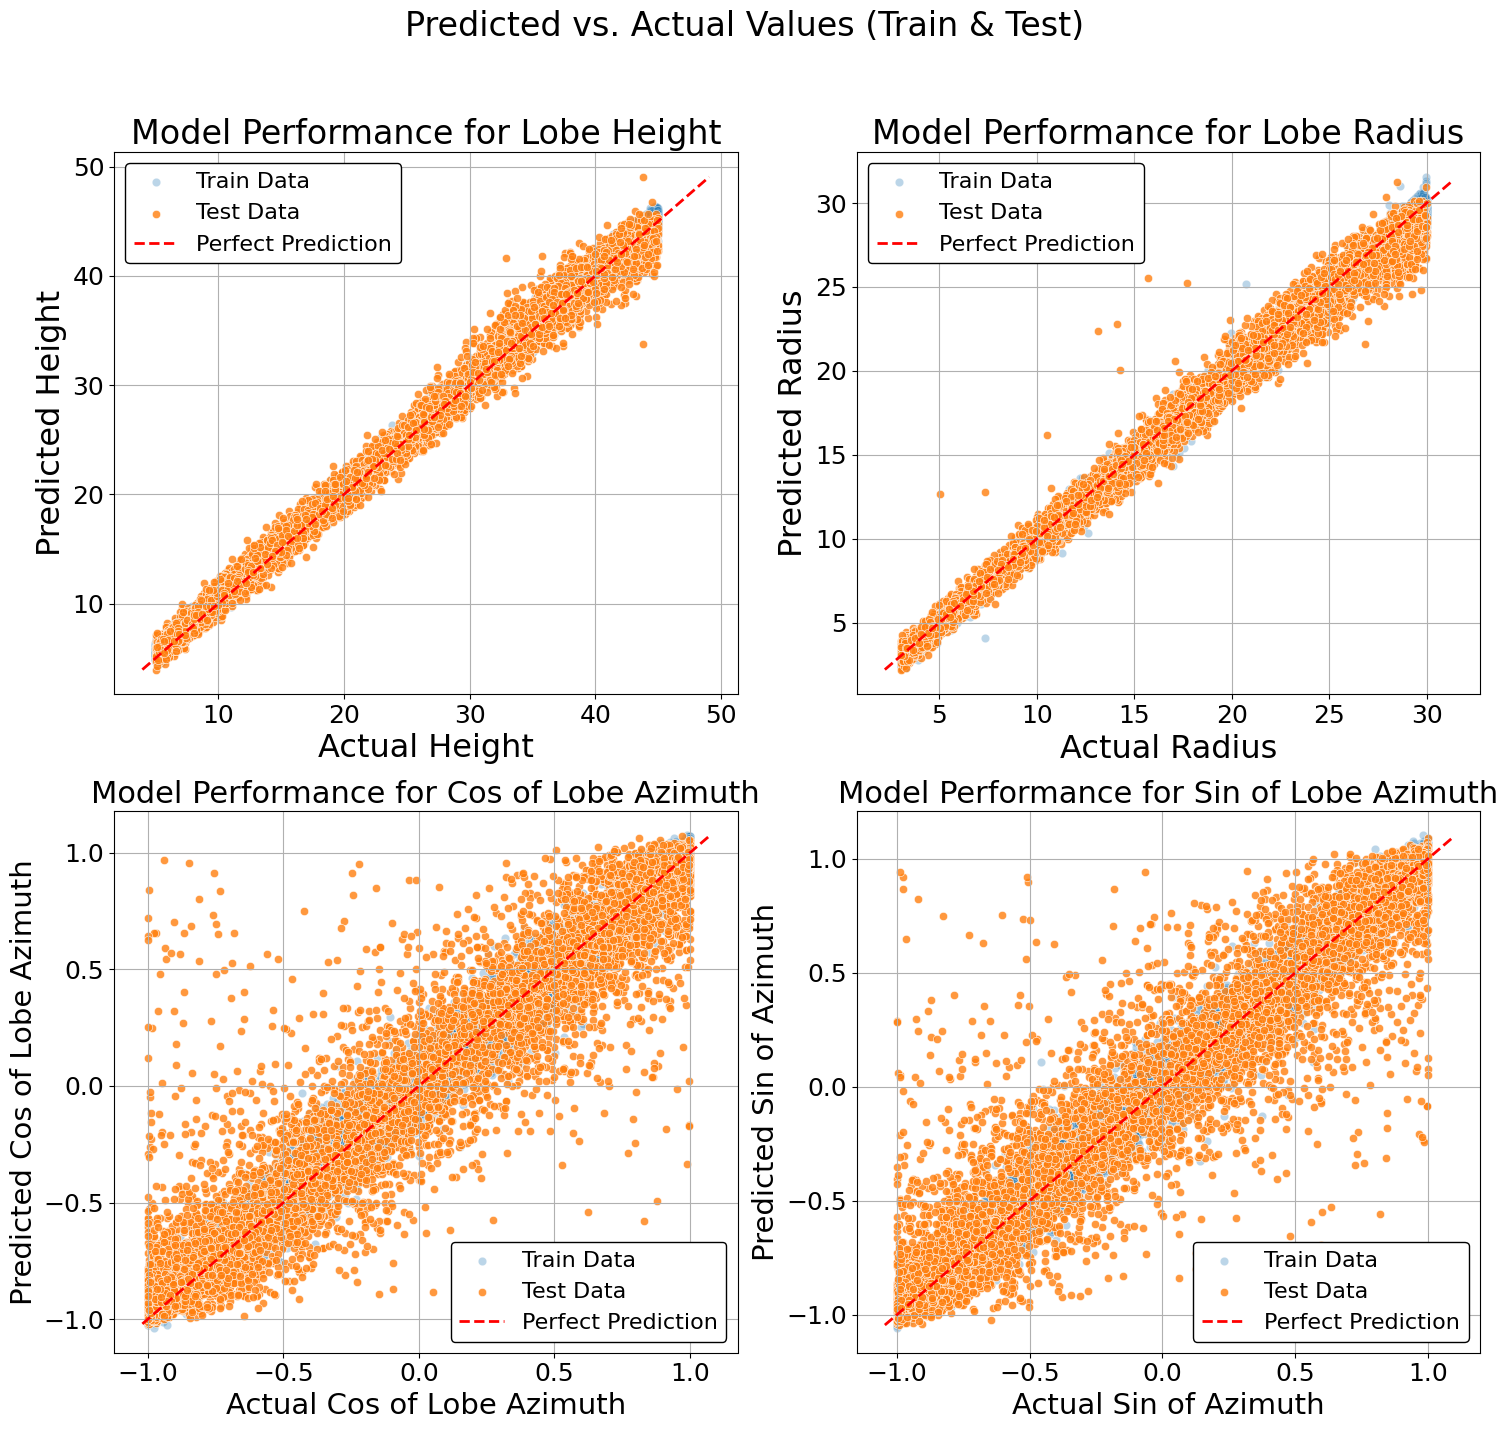

In [78]:
# Legend settings to reuse
legend_params = {
    'fontsize': 16,
    'frameon': True,     # Ensures the box is drawn
    'facecolor': 'white', # Sets background to white
    'edgecolor': 'black', # Optional: adds a black border for definition
    'framealpha': 1      # Ensures the box is 100% opaque
}
# Create a figure with two subplots
plt.style.use('default')
fig, ax = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle('Predicted vs. Actual Values (Train & Test)', fontsize=24)


# --- Plot for Height ---
# Plot training data (light blue, semi-transparent)
sns.scatterplot(x=actual_h_train, y=predicted_h_train, ax=ax[0,0], alpha=0.3, label='Train Data')
# Plot test data (orange, more opaque)
sns.scatterplot(x=actual_h_test, y=predicted_h_test, ax=ax[0,0], alpha=0.8, label='Test Data')

ax[0,0].set_title('Model Performance for Lobe Height', fontsize=24)
ax[0,0].set_xlabel('Actual Height', fontsize=23)
ax[0,0].set_ylabel('Predicted Height', fontsize=23)
min_h, max_h = min(actual_h_test.min(), predicted_h_test.min()), max(actual_h_test.max(), predicted_h_test.max())
ax[0,0].plot([min_h, max_h], [min_h, max_h], 'r--', lw=2, label='Perfect Prediction')
ax[0,0].legend(**legend_params)
ax[0,0].grid(True)
ax[0,0].tick_params(axis='both', labelsize=18)


# --- Plot for Radius ---
# Plot training data
sns.scatterplot(x=actual_r_train, y=predicted_r_train, ax=ax[0,1], alpha=0.3, label='Train Data')
# Plot test data
sns.scatterplot(x=actual_r_test, y=predicted_r_test, ax=ax[0,1], alpha=0.8, label='Test Data')

ax[0,1].set_title('Model Performance for Lobe Radius', fontsize=24)
ax[0,1].set_xlabel('Actual Radius', fontsize=23)
ax[0,1].set_ylabel('Predicted Radius', fontsize=23)
min_r, max_r = min(actual_r_test.min(), predicted_r_test.min()), max(actual_r_test.max(), predicted_r_test.max())
ax[0,1].plot([min_r, max_r], [min_r, max_r], 'r--', lw=2, label='Perfect Prediction')
ax[0,1].legend(**legend_params)
ax[0,1].grid(True)
plt.xticks(fontsize=14, color="black")
ax[0,1].tick_params(axis='both', labelsize=18)


# --- Plot for Aspect Ratio ---
# Plot training data
# sns.scatterplot(x=actual_asp_train, y=predicted_asp_train, ax=ax[1,0], alpha=0.3, label='Train Data')
# # Plot test data
# sns.scatterplot(x=actual_asp_test, y=predicted_asp_test, ax=ax[1,0], alpha=0.8, label='Test Data')

# ax[1,0].set_title('Model Performance for Lobe Aspect Ratio', fontsize=10)
# ax[1,0].set_xlabel('Actual Aspect Ratio', fontsize=23)
# ax[1,0].set_ylabel('Predicted Aspect Ratio', fontsize=23)
# min_r, max_r = min(actual_asp_test.min(), predicted_asp_test.min()), max(actual_asp_test.max(), predicted_asp_test.max())
# ax[1,0].plot([min_r, max_r], [min_r, max_r], 'r--', lw=2, label='Perfect Prediction')
# ax[1,0].legend(**legend_params)
# ax[1,0].grid(True)
# ax[1,0].tick_params(axis='both', labelsize=18)

# # --- Plot for Cos of Angle ---
# # Plot training data
sns.scatterplot(x=actual_anglcos_train, y=predicted_anglcos_train, ax=ax[1,0], alpha=0.3, label='Train Data')
# Plot test data
sns.scatterplot(x=actual_anglcos_test, y=predicted_anglcos_test, ax=ax[1,0], alpha=0.8, label='Test Data')

ax[1,0].set_title('Model Performance for Cos of Lobe Azimuth', fontsize=22)
ax[1,0].set_xlabel('Actual Cos of Lobe Azimuth', fontsize=21)
ax[1,0].set_ylabel('Predicted Cos of Lobe Azimuth', fontsize=21)
min_r, max_r = min(actual_anglcos_test.min(), predicted_anglcos_test.min()), max(actual_anglcos_test.max(), predicted_anglcos_test.max())
ax[1,0].plot([min_r, max_r], [min_r, max_r], 'r--', lw=2, label='Perfect Prediction')
ax[1,0].legend(**legend_params)
ax[1,0].grid(True)
ax[1,0].tick_params(axis='both', labelsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle

# # --- Plot for Sin of Angle ---
# Plot training data
sns.scatterplot(x=actual_anglsin_train, y=predicted_anglsin_train, ax=ax[1,1], alpha=0.3, label='Train Data')
# Plot test data
sns.scatterplot(x=actual_anglsin_test, y=predicted_anglsin_test, ax=ax[1,1], alpha=0.8, label='Test Data')

ax[1,1].set_title('Model Performance for Sin of Lobe Azimuth', fontsize=22)
ax[1,1].set_xlabel('Actual Sin of Azimuth', fontsize=21)
ax[1,1].set_ylabel('Predicted Sin of Azimuth', fontsize=21)
min_r, max_r = min(actual_anglsin_test.min(), predicted_anglsin_test.min()), max(actual_anglsin_test.max(), predicted_anglsin_test.max())
ax[1,1].plot([min_r, max_r], [min_r, max_r], 'r--', lw=2, label='Perfect Prediction')
ax[1,1].legend(**legend_params)
ax[1,1].grid(True)
ax[1,1].tick_params(axis='both', labelsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle




# # --- Plot for Angle ---
# # Plot training data
# sns.scatterplot(x=actual_angl_train_real, y=predicted_angl_train, ax=ax[1,1], alpha=0.3, label='Train Data')
# # Plot test data
# sns.scatterplot(x=actual_angl_test_real, y=predicted_angl_test, ax=ax[1,1], alpha=0.8, label='Test Data')

# ax[1,1].set_title('Model Performance for Lobe Azimuth', fontsize=24)
# ax[1,1].set_xlabel('Actual Azimuth', fontsize=23)
# ax[1,1].set_ylabel('Predicted Azimuth', fontsize=23)
# min_r, max_r = min(actual_angl_test_real.min(), predicted_angl_test.min()), max(actual_angl_test_real.max(), predicted_angl_test.max())
# ax[1,1].plot([min_r, max_r], [min_r, max_r], 'r--', lw=2, label='Perfect Prediction')
# ax[1,1].legend(**legend_params)
# ax[1,1].grid(True)
# ax[1,1].tick_params(axis='both', labelsize=18)
# ax[1,1].set_xlim(-22, 200)
# ax[1,1].set_ylim(-22, 200)
# plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle

plt.savefig("C:/Users/er34726/Downloads/paper4/Fig12.tif", bbox_inches='tight')
plt.show()

## PCA Analysis Results ##
Explained variance by component: [0.305 0.25  0.247 0.198]
Cumulative variance: [0.305 0.555 0.802 1.   ]


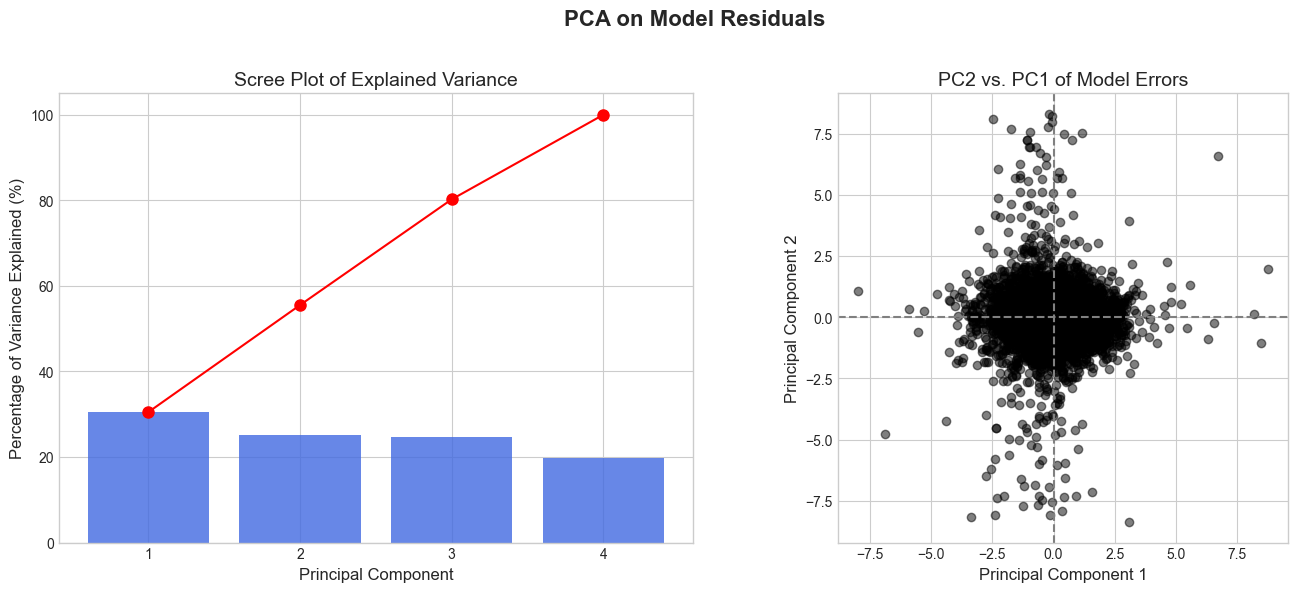

In [70]:
y_true = np.vstack([actual_h_test, actual_r_test, actual_asp_test, actual_angl_test]).T
y_pred = np.vstack([predicted_h_test, predicted_r_test, predicted_asp_test, predicted_angl_test]).T
errors = y_pred - y_true

scaler = StandardScaler()
errors_scaled = scaler.fit_transform(errors)

pca = PCA()
principal_components = pca.fit_transform(errors_scaled)

# --- 4. Analyze and Visualize the Results ---
print("## PCA Analysis Results ##")
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance by component: {np.round(explained_variance, 3)}")
print(f"Cumulative variance: {np.round(np.cumsum(explained_variance), 3)}")

# Create a figure for the plots
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Scree Plot (Explained Variance)
components = np.arange(1, len(explained_variance) + 1)
ax1.bar(components, explained_variance * 100, color='royalblue', alpha=0.8)
ax1.plot(components, np.cumsum(explained_variance * 100), 'ro-', markersize=8)
ax1.set_title('Scree Plot of Explained Variance', fontsize=14)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Percentage of Variance Explained (%)', fontsize=12)
ax1.set_xticks(components)
ax1.set_ylim(0, 105)

# Plot 2: Scatter plot of the first two principal components
# This is the main plot to check for structure
pc1 = principal_components[:, 0]
pc2 = principal_components[:, 1]
ax2.scatter(pc1, pc2, alpha=0.5, c='black') # Color by a feature to see more structure
ax2.set_title('PC2 vs. PC1 of Model Errors', fontsize=14)
ax2.set_xlabel('Principal Component 1', fontsize=12)
ax2.set_ylabel('Principal Component 2', fontsize=12)
ax2.axhline(0, color='grey', linestyle='--')
ax2.axvline(0, color='grey', linestyle='--')
ax2.grid(True)
ax2.set_aspect('equal', adjustable='box') # Make axes scales equal to see true shape

plt.suptitle('PCA on Model Residuals', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("C:/Users/er34726/Downloads/paper4/Fig16.tif", bbox_inches='tight')
plt.show()

In [13]:
print("Height RMSE", np.sqrt(np.mean(np.square(actual_h_test - predicted_h_test))))
print("Radius RMSE", np.sqrt(np.mean(np.square(actual_r_test - predicted_r_test))))
print("Aspect Ratio RMSE", np.sqrt(np.mean(np.square(actual_asp_test - predicted_asp_test))))
print("Angle RMSE", np.sqrt(np.mean(np.square(actual_angl_test - predicted_angl_test))))

Height RMSE 1.1238456
Radius RMSE 0.88325405
Aspect Ratio RMSE 0.12086392
Angle RMSE 10.463475


In [14]:
print("Height RMSE", np.sqrt(np.mean(np.square(actual_h_train - predicted_h_train))))
print("Radius RMSE", np.sqrt(np.mean(np.square(actual_r_train - predicted_r_train))))
print("Aspect Ratio RMSE", np.sqrt(np.mean(np.square(actual_asp_train - predicted_asp_train))))
print("Angle RMSE", np.sqrt(np.mean(np.square(actual_angl_train - predicted_angl_train))))

Height RMSE 0.5579046
Radius RMSE 0.41954434
Aspect Ratio RMSE 0.038976178
Angle RMSE 1.7547348


In [15]:
print("Height R2-score", 1 - np.sqrt(np.mean(np.square(actual_h_test - predicted_h_test))) /
                             np.sqrt(np.mean(np.square(actual_h_test.mean() - actual_h_test))))
print("Radius R2-score", 1 - np.sqrt(np.mean(np.square(actual_r_test - predicted_r_test))) /
                             np.sqrt(np.mean(np.square(actual_r_test.mean() - actual_r_test))))
print("Aspect Ratio R2-score", 1 - np.sqrt(np.mean(np.square(actual_asp_test - predicted_asp_test))) /
                                   np.sqrt(np.mean(np.square(actual_asp_test.mean() - actual_asp_test))))
print("Angle R2-score", 1 - np.sqrt(np.mean(np.square(actual_angl_test - predicted_angl_test))) /
                            np.sqrt(np.mean(np.square(actual_angl_test.mean() - actual_angl_test))))

Height R2-score 0.901363305747509
Radius R2-score 0.8857473805546761
Aspect Ratio R2-score 0.7907582968473434
Angle R2-score 0.7997071295976639


In [16]:
print("Height R2-score", 1 - np.sqrt(np.mean(np.square(actual_h_train - predicted_h_train))) /
                             np.sqrt(np.mean(np.square(actual_h_train.mean() - actual_h_train))))
print("Radius R2-score", 1 - np.sqrt(np.mean(np.square(actual_r_train - predicted_r_train))) /
                             np.sqrt(np.mean(np.square(actual_r_train.mean() - actual_r_train))))
print("Aspect Ratio R2-score", 1 - np.sqrt(np.mean(np.square(actual_asp_train - predicted_asp_train))) /
                                   np.sqrt(np.mean(np.square(actual_asp_train.mean() - actual_asp_train))))
print("Angle R2-score", 1 - np.sqrt(np.mean(np.square(actual_angl_train - predicted_angl_train))) /
                            np.sqrt(np.mean(np.square(actual_angl_train.mean() - actual_angl_train))))

Height R2-score 0.9515032544732094
Radius R2-score 0.946169875562191
Aspect Ratio R2-score 0.9324475154280663
Angle R2-score 0.9662022814154625


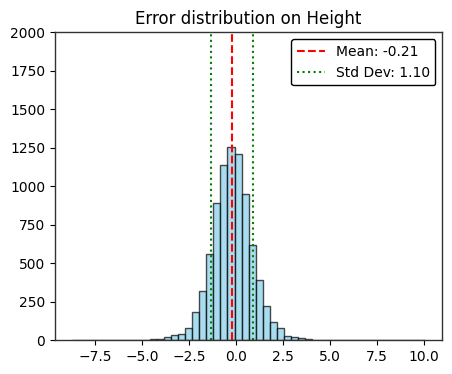

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Your existing setup
plt.rcParams['axes.edgecolor'] = '#333333'  # Sets all plot outlines to black
plt.rcParams['axes.linewidth'] = 1      # Makes the outlines slightly thicker/bolder
plt.figure(figsize=(5,4))
# 1. REMOVE GRID LINES
ax = plt.gca()
plt.hist(actual_h_test - predicted_h_test, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.ylim(0, 2000)
plt.title("Error distribution on Height")

# 1. REMOVE GRID LINES
plt.grid(False)

# Calculate stats
errors = actual_h_test - predicted_h_test
mean_val = np.mean(errors)
std_dev_error = np.std(errors)

# Vertical lines
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, label=f"Mean: {mean_val:.2f}")
plt.axvline(mean_val + std_dev_error, color='green', linestyle=':', linewidth=1.5, label=f'Std Dev: {std_dev_error:.2f}')
plt.axvline(mean_val - std_dev_error, color='green', linestyle=':', linewidth=1.5)

plt.legend(**{
    'fontsize': 10,
    'frameon': True,     # Ensures the box is drawn
    'facecolor': 'white', # Sets background to white
    'edgecolor': 'black', # Optional: adds a black border for definition
    'framealpha': 1      # Ensures the box is 100% opaque
}, loc='upper right')

plt.savefig("C:/Users/er34726/Downloads/paper4/Fig13a.tif", bbox_inches='tight')
plt.show()

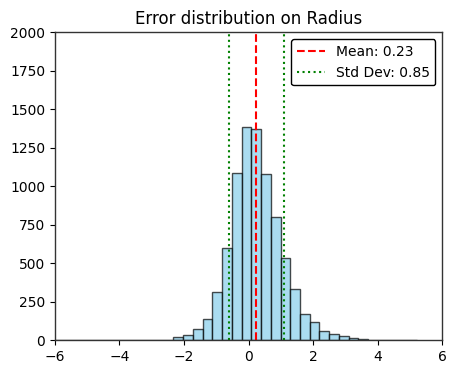

In [67]:

plt.rcParams['axes.edgecolor'] = '#333333'  # Sets all plot outlines to black
plt.rcParams['axes.linewidth'] = 1      # Makes the outlines slightly thicker/bolder
plt.figure(figsize=(5,4))
# 1. REMOVE GRID LINES
ax = plt.gca()
# 1. REMOVE GRID LINES
plt.grid(False)
plt.hist(actual_r_test - predicted_r_test,bins=50,color='skyblue',edgecolor='black', alpha=0.7)
plt.ylim(0,2000)
plt.xlim(-6,6)
std_dev_error = np.std(actual_r_test - predicted_r_test) # Standard Deviation is the sqrt of variance

plt.axvline(np.mean(actual_r_test - predicted_r_test), color='red', linestyle='dashed', linewidth=1.5, label=f"Mean: {np.mean(actual_r_test - predicted_r_test):.2f}")
# Plot the standard deviation lines in green
plt.axvline(np.mean(actual_r_test - predicted_r_test) + std_dev_error, color='green', linestyle=':', linewidth=1.5, label=f'Std Dev: {std_dev_error:.2f}')
plt.axvline(np.mean(actual_r_test - predicted_r_test) - std_dev_error, color='green', linestyle=':', linewidth=1.5)
plt.legend()
plt.title("Error distribution on Radius")
plt.legend(**{
    'fontsize': 10,
    'frameon': True,     # Ensures the box is drawn
    'facecolor': 'white', # Sets background to white
    'edgecolor': 'black', # Optional: adds a black border for definition
    'framealpha': 1      # Ensures the box is 100% opaque
}, loc='upper right')

plt.savefig("C:/Users/er34726/Downloads/paper4/Fig13b.tif", bbox_inches='tight')
plt.show()

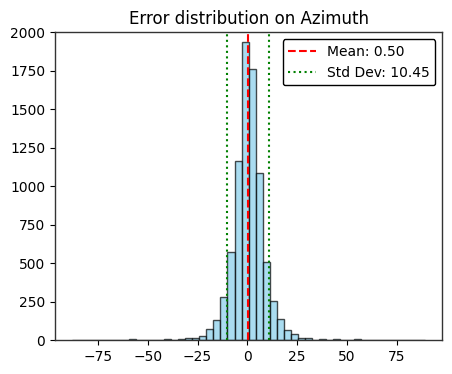

In [68]:

plt.rcParams['axes.edgecolor'] = '#333333'  # Sets all plot outlines to black
plt.rcParams['axes.linewidth'] = 1      # Makes the outlines slightly thicker/bolder
plt.figure(figsize=(5,4))
# 1. REMOVE GRID LINES
ax = plt.gca()
plt.grid(False)
plt.hist(actual_angl_test - predicted_angl_test,bins=50, color='skyblue',edgecolor='black', alpha=0.7)
plt.ylim(0,2000)
plt.title("Error distribution on Azimuth")
std_dev_error = np.std(actual_angl_test - predicted_angl_test) # Standard Deviation is the sqrt of variance

plt.axvline(np.mean(actual_angl_test - predicted_angl_test), color='red', linestyle='dashed', linewidth=1.5, label=f"Mean: {np.mean(actual_angl_test - predicted_angl_test):.2f}")
# Plot the standard deviation lines in green
plt.axvline(np.mean(actual_angl_test - predicted_angl_test) + std_dev_error, color='green', linestyle=':', linewidth=1.5, label=f'Std Dev: {std_dev_error:.2f}')
plt.axvline(np.mean(actual_angl_test - predicted_angl_test) - std_dev_error, color='green', linestyle=':', linewidth=1.5)
plt.legend(**{
    'fontsize': 10,
    'frameon': True,     # Ensures the box is drawn
    'facecolor': 'white', # Sets background to white
    'edgecolor': 'black', # Optional: adds a black border for definition
    'framealpha': 1      # Ensures the box is 100% opaque
},loc='upper right')
plt.savefig("C:/Users/er34726/Downloads/paper4/Fig13d.tif", bbox_inches='tight')
plt.show()

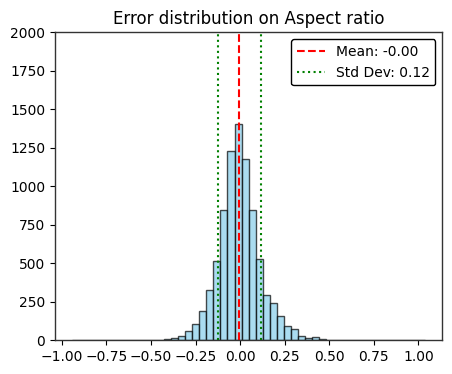

In [69]:

plt.rcParams['axes.edgecolor'] = '#333333'  # Sets all plot outlines to black
plt.rcParams['axes.linewidth'] = 1      # Makes the outlines slightly thicker/bolder
plt.figure(figsize=(5,4))
# 1. REMOVE GRID LINES
ax = plt.gca()
# 1. REMOVE GRID LINES
plt.grid(False)
plt.hist(actual_asp_test - predicted_asp_test,bins=50,color='skyblue',edgecolor='black', alpha=0.7)
plt.title("Error distribution on Aspect ratio")
plt.ylim(0,2000)
std_dev_error = np.std(actual_asp_test - predicted_asp_test) # Standard Deviation is the sqrt of variance

plt.axvline(np.mean(actual_asp_test - predicted_asp_test), color='red', linestyle='dashed', linewidth=1.5, label=f"Mean: {np.mean(actual_asp_test - predicted_asp_test):.2f}")
# Plot the standard deviation lines in green
plt.axvline(np.mean(actual_asp_test - predicted_asp_test) + std_dev_error, color='green', linestyle=':', linewidth=1.5, label=f'Std Dev: {std_dev_error:.2f}')
plt.axvline(np.mean(actual_asp_test - predicted_asp_test) - std_dev_error, color='green', linestyle=':', linewidth=1.5)
plt.legend(**{
    'fontsize': 10,
    'frameon': True,     # Ensures the box is drawn
    'facecolor': 'white', # Sets background to white
    'edgecolor': 'black', # Optional: adds a black border for definition
    'framealpha': 1      # Ensures the box is 100% opaque
}, loc='upper right')
plt.savefig("C:/Users/er34726/Downloads/paper4/Fig13c.tif", bbox_inches='tight')
plt.show()